<a href="https://colab.research.google.com/github/Arun1859/Python__Tasks/blob/master/SmartBite_Analytics_Restaurant_Insights_%26_Rating_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartBite Analytics: Restaurant Insights & Rating Prediction System

# 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# 2. Load Dataset

In [5]:
import csv
csv.field_size_limit(10**7)
df = pd.read_csv('/content/zomato.csv', engine='python', on_bad_lines='skip')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


# 3.  Data Understanding

In [6]:
df.shape

(51717, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [8]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [9]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

# 4. Data Cleaning and Preparation

In [ ]:
# Data Cleaning
Steps Performed
-Standardizing column name
-Handling missing Values
-Removing Duplicates
-Removing data types

column cleaning

In [10]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

Missing Values

In [11]:
df.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21
rest_type,227


We remove missing values for simplicity and data consistency.

In [37]:
# Handle missing values smartly
df['rate'] = df['rate'].fillna(df['rate'].mode()[0])
df['approx_cost(for_two_people)'] = df['approx_cost(for_two_people)'].fillna(df['approx_cost(for_two_people)'].median())
df['location'] = df['location'].fillna('Unknown')

df.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,0
votes,0
phone,0
location,0
rest_type,0


In [ ]:
# Instead of removing all missing values, we handled them using statistical techniques such as mode and median. This helps preserve data size and improves analysis quality.

Remove Duplicates

In [39]:
df = df.drop_duplicates().copy()
df

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for_two_people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51703,https://www.zomato.com/bangalore/olivers-pub-d...,"ITPL Ascendas Park Square Mall, ITPL, First Fl...",Oliver's Pub & Diner,Yes,Yes,3.9,548,+91 8043691111\n+91 8028026519,Whitefield,"Pub, Casual Dining","Pizza, Beer, Cocktails, Nachos, Pasta, Moo Bur...","Finger Food, American, Continental, Burger, Pizza",1500,"[('Rated 4.0', ""RATED\n I had :-\n\n1. Italia...",[],Pubs and bars,Whitefield
51704,https://www.zomato.com/bangalore/smaaash-white...,"2nd Floor, Phoenix Market City, Whitefield, Ba...",Smaaash,No,Yes,4.0,189,+91 9900069474\n+91 7899644468,Whitefield,"Casual Dining, Pub","Pizza, Beer","North Indian, Pizza, Chinese",1500,"[('Rated 3.0', 'RATED\n Like this place for z...",[],Pubs and bars,Whitefield
51705,https://www.zomato.com/bangalore/izakaya-gastr...,"2nd Floor, Iona, Virginia Mall, Whitefield Mai...",Izakaya Gastro Pub,Yes,Yes,3.8,128,+91 7625087121\n+91 8050587483,Whitefield,"Bar, Casual Dining","Beer, Chicken Guntur, Paneer Tikka, Fish, Nood...","North Indian, Continental, Mediterranean",1200,"[('Rated 3.0', ""RATED\n Nice place to hangout...",[],Pubs and bars,Whitefield
51708,https://www.zomato.com/bangalore/keys-cafe-key...,"Keys Hotel, 6, 1st Phase Industrial Area, Near...",Keys Cafe - Keys Hotel,No,No,2.8,161,080 39451000\n+91 8884038484,Whitefield,"Casual Dining, Bar","Salads, Coffee, Breakfast Buffet, Halwa, Chick...","Chinese, Continental, North Indian",1200,"[('Rated 3.0', 'RATED\n Place is good not tha...",[],Pubs and bars,Whitefield


In [40]:
df.rename(columns={'approx_cost(for_two_people)': 'cost_for_two'}, inplace=True)

Data Type Conversion

In [42]:
df = df.copy()

df['rate'] = df['rate'].astype(str).str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df['cost_for_two'] = df['cost_for_two'].astype(str).str.replace(',', '')
df['cost_for_two'] = pd.to_numeric(df['cost_for_two'], errors='coerce')

# 6. Outlier Detection & Treatment

In [ ]:
# Outlier Detection
We use boxplots and IQR method to detect and remove extreme values.

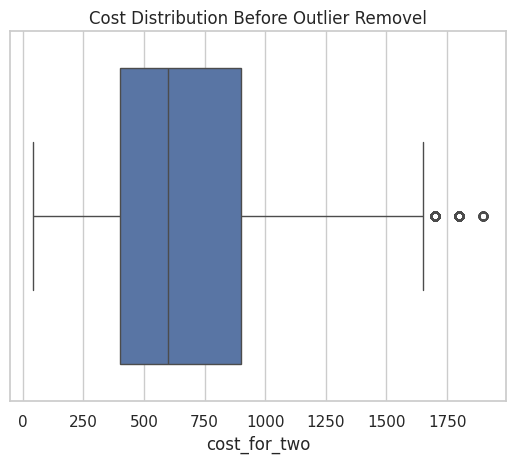

In [44]:
sns.boxplot(x=df['cost_for_two'])
plt.title("Cost Distribution Before Outlier Removel")
plt.show()

In [46]:
Q1 = df['cost_for_two'].quantile(0.25)
Q3 = df['cost_for_two'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['cost_for_two'] >= Q1 - 1.5*IQR) &
        (df['cost_for_two'] <= Q3 + 1.5*IQR)]

# 6. Check Data Balance

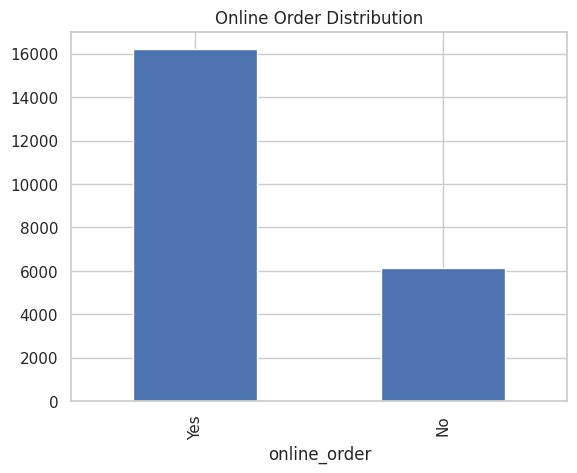

In [17]:
df['online_order'].value_counts().plot(kind='bar', title='Online Order Distribution')
plt.show()

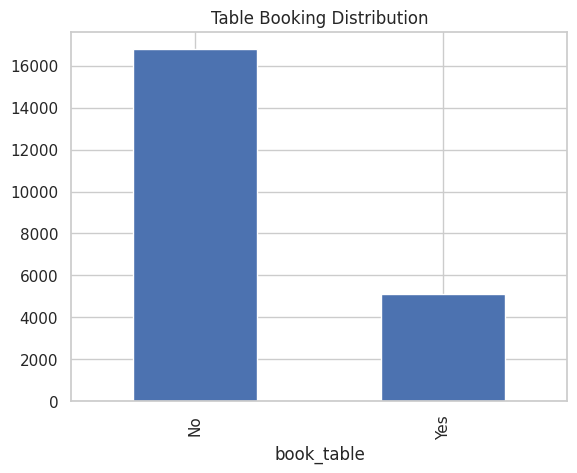

In [47]:
df['book_table'].value_counts().plot(kind='bar', title='Table Booking Distribution')
plt.show()

# EDA SECTION

# 7. Univariate Analysis

In [19]:
# Analyzing individual features.
## Univariate Analysis

Univariate analysis focuses on analyzing individual variables to understand their distribution and characteristics.

*******Rating Distribution*******

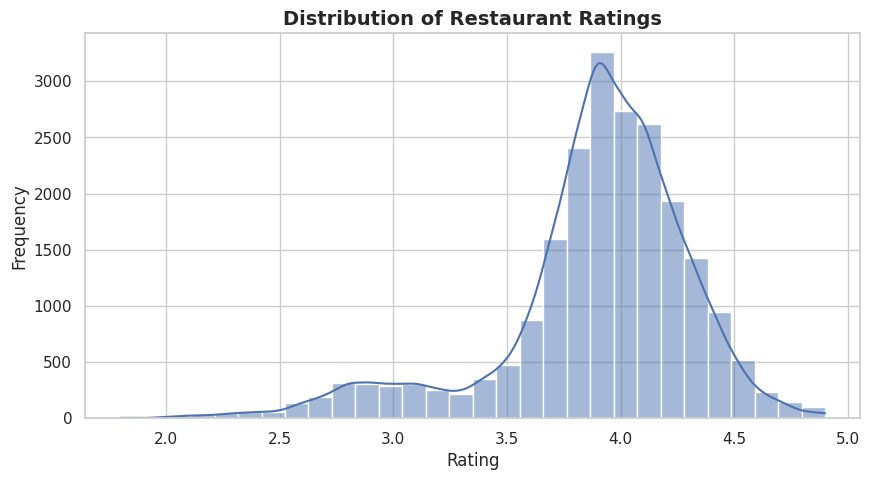

In [50]:
plt.figure(figsize=(10,5))
sns.histplot(df['rate'], bins=30, kde=True)

plt.title("Distribution of Restaurant Ratings", fontsize=14, fontweight='bold')
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

In [51]:
# - Most restaurants are rated between 3.5 and 4.5
# - Indicates consistent service quality across restaurants

*****Restaurent Types*****

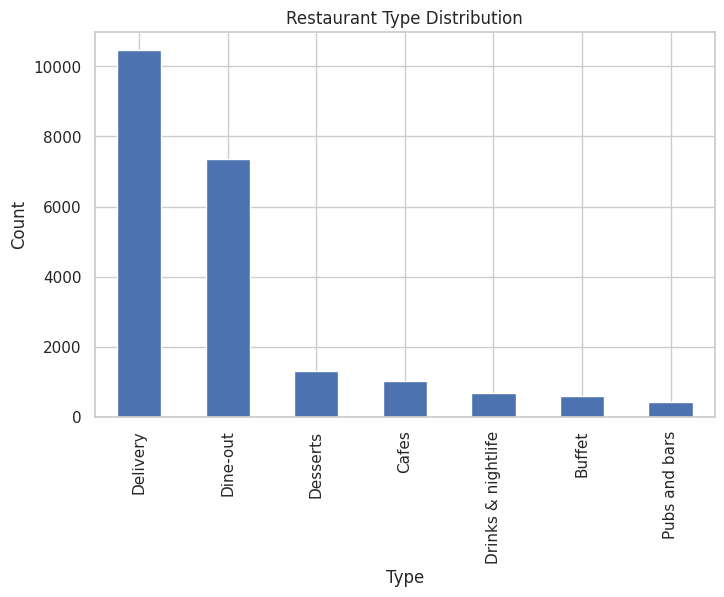

In [59]:
df['listed_in(type)'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Restaurant Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

# 8. Bivariate Analysis

In [22]:
# Understanding relationships between two variables
## Bivariate Analysis

Bivariate analysis helps identify relationships between two variables, such as how cost influences ratings.

*****Online Order vs Rating*****

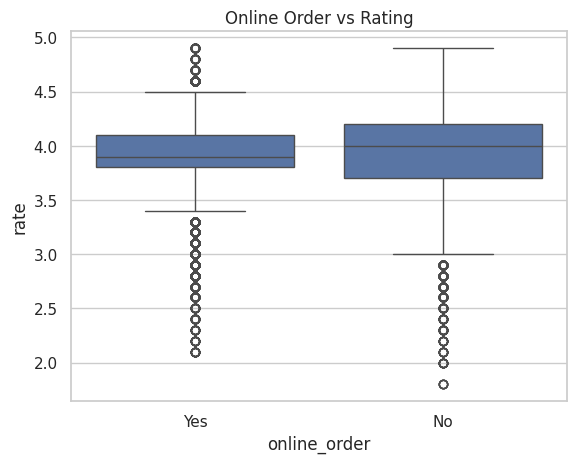

In [23]:
sns.boxplot(x='online_order', y='rate', data=df)
plt.title("Online Order vs Rating")
plt.show()

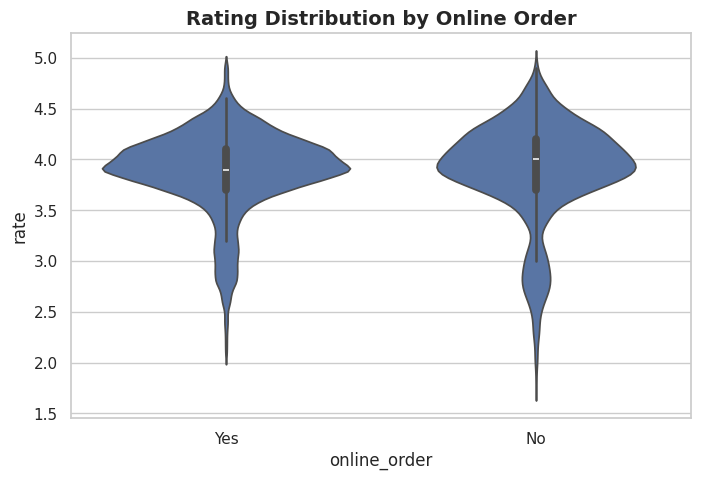

In [55]:
plt.figure(figsize=(8,5))
sns.violinplot(x='online_order', y='rate', data=df)

plt.title("Rating Distribution by Online Order", fontsize=14, fontweight='bold')
plt.show()

*****Cost vs Rating*****

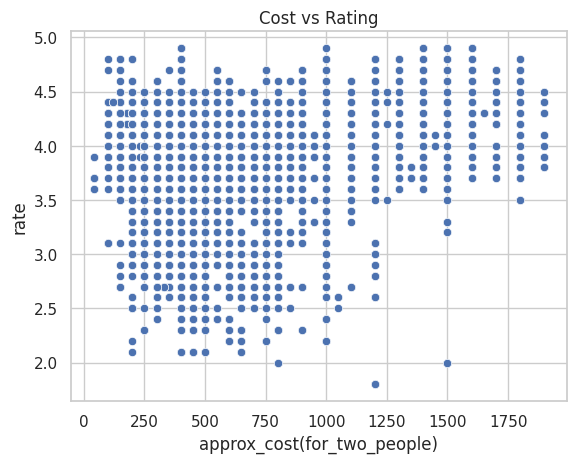

In [24]:
sns.scatterplot(x='approx_cost(for_two_people)', y='rate', data=df)
plt.title("Cost vs Rating")
plt.show()

# 10. Multivariate Analysis

In [25]:
# Analysing relationships among multiple variable
## Multivariate Analysis

Multivariate analysis examines interactions among multiple variables to uncover deeper insights.

*****Correlation Heatmap*****

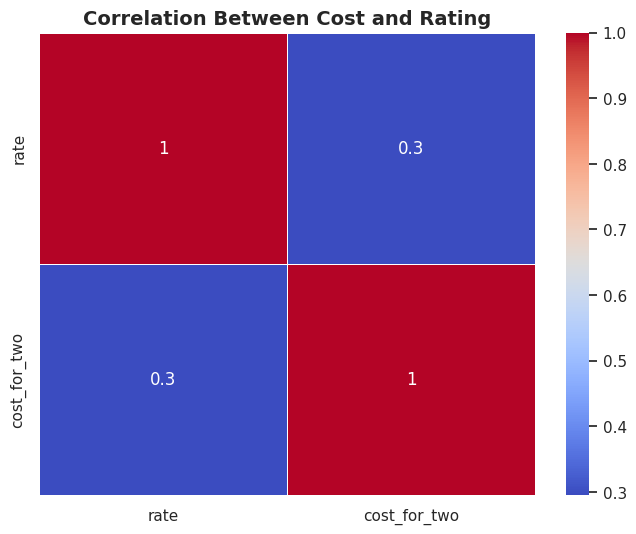

In [52]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['rate','cost_for_two']].corr(), annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Between Cost and Rating", fontsize=14, fontweight='bold')
plt.show()

# 10. Location Analysis

In [27]:
# Top Restaurant Location

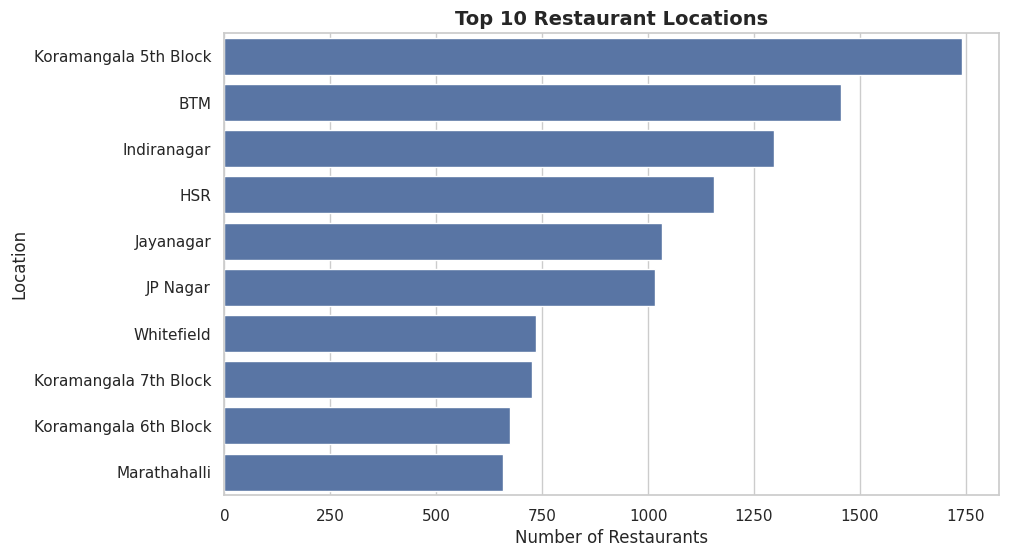

In [54]:
top_loc = df['location'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_loc.values, y=top_loc.index)

plt.title("Top 10 Restaurant Locations", fontsize=14, fontweight='bold')
plt.xlabel("Number of Restaurants")
plt.ylabel("Location")
plt.show()

# 10. Pivot Table Analysis

In [31]:
pivot = pd.pivot_table(df,
                       values='rate',
                       index='location',
                       columns='online_order',
                       aggfunc='mean')
pivot.head()

online_order,No,Yes
location,,
BTM,3.754086,3.758032
Banashankari,3.753922,3.834737
Banaswadi,3.702500,3.620513
Bannerghatta Road,3.526786,3.727604
Basavanagudi,3.823077,3.846040


*****Top Rated Restaurents*****

In [32]:
df.sort_values(by='rate', ascending=False).head(10)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for_two_people),reviews_list,menu_item,listed_in(type),listed_in(city)
49627,https://www.zomato.com/bangalore/byg-brewski-b...,"Behind MK Retail, Sarjapur Road, Bangalore",Byg Brewski Brewing Company,Yes,Yes,4.9,16832,+91 8039514766,Sarjapur Road,Microbrewery,"Cocktails, Butter Chicken, Dahi Kebab, Rajma C...","Continental, North Indian, Italian, South Indi...",1600,"[('Rated 4.0', 'RATED\n Visiting a microbrewe...",[],Dine-out,Sarjapur Road
43055,https://www.zomato.com/bangalore/belgian-waffl...,"65, Markham Road, Ashok Nagar, Brigade Road, B...",Belgian Waffle Factory,Yes,No,4.9,1750,+91 9481511911,Brigade Road,Dessert Parlor,"Coffee, Berryblast, Nachos, Chocolate Waffles,...",Desserts,400,"[('Rated 4.0', ""RATED\n Looks like there's a ...","['The Red Wonder Waffle [Bubble]', 'Bubble Kit...",Desserts,MG Road
4801,https://www.zomato.com/bangalore/byg-brewski-b...,"Behind MK Retail, Sarjapur Road, Bangalore",Byg Brewski Brewing Company,Yes,Yes,4.9,16345,+91 8039514766,Sarjapur Road,Microbrewery,"Cocktails, Dahi Kebab, Rajma Chawal, Butter Ch...","Continental, North Indian, Italian, South Indi...",1600,"[('Rated 5.0', 'RATED\n I have been to this p...","['Creamy Mushroom and Truffle Soup', 'Kung Pao...",Dine-out,Bellandur
11745,https://www.zomato.com/bangalore/belgian-waffl...,"65, Markham Road, Ashok Nagar, Brigade Road, B...",Belgian Waffle Factory,Yes,No,4.9,1744,+91 9481511911,Brigade Road,Dessert Parlor,"Coffee, Berryblast, Nachos, Chocolate Waffles,...",Desserts,400,"[('Rated 3.0', ""RATED\n Waffles are totally w...",[],Delivery,Church Street
10389,https://www.zomato.com/bangalore/abs-absolute-...,"100 Feet Road, 1st Phase, Near Jayadeva Flyove...",AB's - Absolute Barbecues,No,Yes,4.9,6375,040 45659912,BTM,Casual Dining,"Tangdi Chicken, Bbq Buffet, Chocolate Icecream...","European, Mediterranean, North Indian, BBQ",1600,"[('Rated 5.0', 'RATED\n We liked the place a ...",[],Dine-out,BTM
27453,https://www.zomato.com/bangalore/asia-kitchen-...,"136, Ground Floor, 1st Cross, 5th Block, Jyoti...",Asia Kitchen By Mainland China,Yes,Yes,4.9,2217,080 49652573,Koramangala 5th Block,"Casual Dining, Bar","Chicken Dim Sum, Pad Thai Noodle, Jumbo Prawns...","Asian, Chinese, Thai, Momos",1500,"[('Rated 5.0', ""RATED\n Everything from the a...",[],Delivery,Koramangala 4th Block
23587,https://www.zomato.com/bangalore/abs-absolute-...,"100 Feet Road, 1st Phase, Near Jayadeva Flyove...",AB's - Absolute Barbecues,No,Yes,4.9,6404,040 45659912,BTM,Casual Dining,"Tangdi Chicken, Bbq Buffet, Chocolate Icecream...","European, Mediterranean, North Indian, BBQ",1600,"[('Rated 5.0', ""RATED\n Best place for buffet...",[],Dine-out,JP Nagar
5809,https://www.zomato.com/bangalore/belgian-waffl...,"65, Markham Road, Ashok Nagar, Brigade Road, B...",Belgian Waffle Factory,Yes,No,4.9,1746,+91 9481511911,Brigade Road,Dessert Parlor,"Coffee, Berryblast, Nachos, Chocolate Waffles,...",Desserts,400,"[('Rated 3.0', ""RATED\n Waffles are totally w...",[],Desserts,Brigade Road
47409,https://www.zomato.com/bangalore/belgian-waffl...,"65, Markham Road, Ashok Nagar, Brigade Road, B...",Belgian Waffle Factory,Yes,No,4.9,1749,+91 9481511911,Brigade Road,Dessert Parlor,"Coffee, Berryblast, Nachos, Chocolate Waffles,...",Desserts,400,"[('Rated 4.0', ""RATED\n Looks like there's a ...",[],Delivery,Residency Road
10879,https://www.zomato.com/bangalore/asia-kitchen-...,"136, Ground Floor, 1st Cross, 5th Block, Jyoti...",Asia Kitchen By Mainland China,Yes,Yes,4.9,2178,080 49652573,Koramangala 5th Block,"Casual Dining, Bar","Noodles, Chicken Dim Sum, Pad Thai Noodle, Jum...","Asian, Chinese, Thai, Momos",1500,"[('Rated 5.0', ""RATED\n This is not just one ...","['Vegetable Eight Treasure Soup', 'Chicken Swe...",Dine-out,BTM


*****Most Expensive Restaurants*****

In [33]:
df.sort_values(by='approx_cost(for_two_people)', ascending=False).head(10)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for_two_people),reviews_list,menu_item,listed_in(type),listed_in(city)
43452,https://www.zomato.com/bangalore/northern-gate...,"Gateway Hotel, 66, Residency Road, Bangalore",Northern Gate- Gateway Hotel,No,Yes,4.0,103,+91 9845547532\n+91 9898780004,Residency Road,Casual Dining,"Cut Fruits, Pasta, Sunday Brunch",North Indian,1900,"[('Rated 3.0', 'RATED\n Located at one of the...",[],Dine-out,MG Road
6082,https://www.zomato.com/bangalore/rocksalt-st-m...,"3rd Floor, 15, Madras Bank Road/ Museum Road, ...",RockSalt,Yes,Yes,4.4,484,+91 9740255099\r\r\n080 48909678,St. Marks Road,"Bar, Casual Dining","Roti, Cocktails, Chicken Biryani, Paratha, Dah...",Modern Indian,1900,"[('Rated 4.0', 'RATED\n What a great place ! ...",[],Dine-out,Brigade Road
51051,https://www.zomato.com/bangalore/alt-whitefiel...,"Sky Deck, VR Bengaluru, Whitefield Main Road, ...",alt,No,Yes,4.1,821,080 49653221,Whitefield,"Bar, Lounge","Margarita, Lamb, Cocktails, Nachos, Spring Rol...",Finger Food,1900,"[('Rated 3.0', ""RATED\n It's a skydeck which ...",[],Dine-out,Whitefield
4967,https://www.zomato.com/bangalore/opus-club-1-s...,"26, Varthur Hobli, Near HP Petrol Bunk, Harlur...",OPUS Club,No,Yes,4.4,1496,+91 8046444777\r\n+91 7349734900,Sarjapur Road,Pub,"Biryani, Cocktails, Nachos, Mocktails, Long Is...","Continental, Italian, North Indian, Mexican",1900,"[('Rated 4.0', 'RATED\n OPUS Club\n\nAfter he...",[],Pubs and bars,Bellandur
4947,https://www.zomato.com/bangalore/opus-club-1-s...,"26, Varthur Hobli, Near HP Petrol Bunk, Harlur...",OPUS Club,No,Yes,4.4,1496,+91 8046444777\r\n+91 7349734900,Sarjapur Road,Pub,"Biryani, Cocktails, Nachos, Mocktails, Long Is...","Continental, Italian, North Indian, Mexican",1900,"[('Rated 4.0', 'RATED\n OPUS Club\n\nAfter he...",[],Drinks & nightlife,Bellandur
4949,https://www.zomato.com/bangalore/opus-club-1-s...,"26, Varthur Hobli, Near HP Petrol Bunk, Harlur...",OPUS Club,No,Yes,4.4,1496,+91 8046444777\r\n+91 7349734900,Sarjapur Road,Pub,"Biryani, Cocktails, Nachos, Mocktails, Long Is...","Continental, Italian, North Indian, Mexican",1900,"[('Rated 4.0', 'RATED\n OPUS Club\n\nAfter he...",[],Drinks & nightlife,Bellandur
51683,https://www.zomato.com/bangalore/alt-whitefiel...,"Sky Deck, VR Bengaluru, Whitefield Main Road, ...",alt,No,Yes,4.1,821,080 49653221,Whitefield,"Bar, Lounge","Margarita, Lamb, Cocktails, Nachos, Spring Rol...",Finger Food,1900,"[('Rated 3.0', ""RATED\n It's a skydeck which ...",[],Pubs and bars,Whitefield
4875,https://www.zomato.com/bangalore/equinox-bar-d...,"DoubleTree Suites by Hilton, Iblur Gate, Outer...",Equinox Bar - DoubleTree Suites By Hilton,No,Yes,3.9,52,+91 8861301373\r\n+91 8861306613,Sarjapur Road,Lounge,Cocktails,"Continental, Thai, Vietnamese, American, Chine...",1900,"[('Rated 4.0', 'RATED\n Quiet \U0001f92b and ...",[],Dine-out,Bellandur
6264,https://www.zomato.com/bangalore/northern-gate...,"Gateway Hotel, 66, Residency Road, Bangalore",Northern Gate- Gateway Hotel,No,Yes,3.9,100,+91 9845547532\r\n+91 9898780004,Residency Road,Casual Dining,"Cut Fruits, Pasta, Sunday Brunch",North Indian,1900,"[('Rated 3.0', 'RATED\n Located at one of the...",[],Dine-out,Brigade Road
39342,https://www.zomato.com/bangalore/rocksalt-st-m...,"3rd Floor, 15, Madras Bank Road/ Museum Road, ...",RockSalt,Yes,Yes,4.4,494,+91 9740255099\n080 48909678,St. Marks Road,"Bar, Casual Dining","Roti, Cocktails, Chicken Biryani, Paratha, Dah...",Modern Indian,1900,"[('Rated 4.0', 'RATED\n Well now this was a v...",[],Drinks & nightlife,Lavelle Road


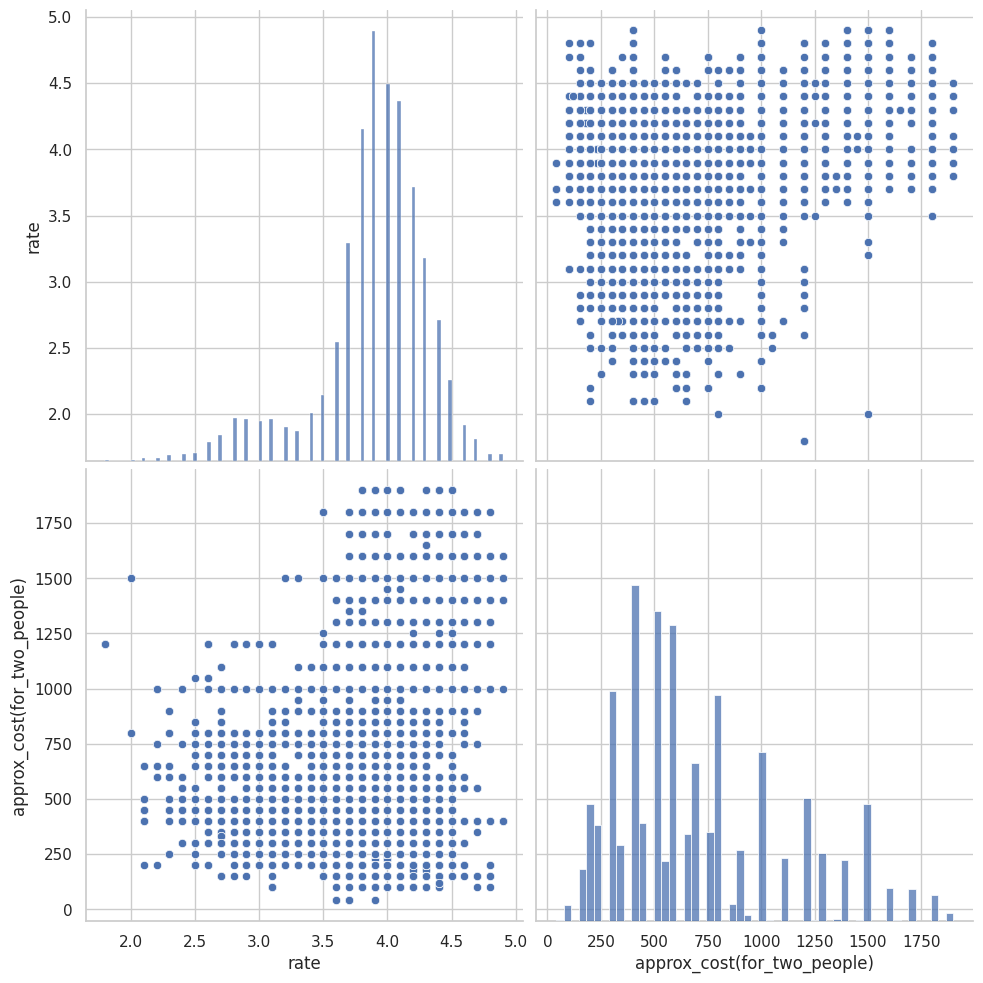

In [35]:
sns.pairplot(df[['rate','approx_cost(for_two_people)']], height=5)
plt.show()

# 11. Final Insights

In [ ]:
## Key Insights

- Majority of restaurants fall within a mid-price range, indicating affordability for average customers
- Restaurants offering online ordering tend to have slightly higher ratings, suggesting convenience improves customer satisfaction
- Certain locations have a higher concentration of restaurants, indicating business hotspots
- High-cost restaurants do not necessarily guarantee higher ratings, highlighting the importance of service quality
- Table booking is less common, indicating most restaurants operate on a walk-in or online-order basis

# 12. Conclusion

In [ ]:
##Conclusion
This project demonstrates how raw data can be transformed into meaningful insights using data cleaning, visualization, and analysis techniques.
The findings can help businesses improve pricing strategies, customer experience, and location-based decisions.